# 28_01 혼동행렬 기반 분류 평가

In [159]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['Malgun Gothic']


# 01 정확도와 그 한계
모델 채점의 첫 단추 — 정확도의 정의, 그리고 불균형이 만드는 함정


### accuracy_score()로 정확도 구하기
정답을 먼저, 예측을 나중에 — 앞으로 모든 지표 함수가 따르는 인자 순서

In [160]:
# 코드

### 데이터 로드와 X·y 분리
CSV를 불러와 입력 X(센서 6종)와 정답 y(failure_soon)으로 분리


In [161]:
df = pd.read_csv('28_cmapss_fd001_sample.csv')
feature_cols = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_11', 'sensor_15']
X = df[feature_cols]
y = df['failure_soon']

### 분할·학습·예측
학습용·평가용으로 나눠 `RandomForest` 학습 후 예측 — 오늘 채점의 재료


In [162]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

Xtr, X_test, ytr, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42).fit(Xtr, ytr)
y_pred = model.predict(X_test)

y_pred[:15]

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0])

### 손계산과 함수 대조
같은 자리의 개수를 직접 세어 전체로 나눈 값과 함수 결과 비교

In [163]:
correct = (y_test == y_pred).sum()

total = len(y_test)
print('직접 계산', correct / total)


from sklearn.metrics import accuracy_score

print('함수 결과', accuracy_score(y_test, y_pred))

직접 계산 0.87
함수 결과 0.87


### 더미 분류기로 기준선 만들기
`most_frequent` 전략 — 항상 가장 많은 클래스로만 예측하는 모델

In [164]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(Xtr, ytr)
print("베이스라인: ", dummy.score(X_test, y_test))

베이스라인:  0.8


### 클래스 비율 확인
정상(0)과 고장 임박(1)의 개수·비율 확인 — 1이 얼마나 적은지 눈으로 확인


In [165]:
print(y.value_counts())
print(y.value_counts(normalize=True))

failure_soon
0    781
1    219
Name: count, dtype: int64
failure_soon
0    0.781
1    0.219
Name: proportion, dtype: float64


### 무조건 정상 예측의 정확도
모두 정상으로 찍어도 정확도가 꽤 높음 — 함정을 눈으로 확인하는 순간


In [166]:
all_normal = np.zeros(len(y_test))
print("무조건 정상", accuracy_score(y_test, all_normal))

무조건 정상 0.8


### 두 모델 정확도 출력
더미와 모델의 정확도를 나란히 출력 — 두 숫자를 비교할 준비


In [167]:
dummy_acc = dummy.score(X_test, y_test)
print('베이스라인: ', dummy_acc)

model_acc = model.score(X_test, y_test)
print('우리 모델: ', model_acc)


베이스라인:  0.8
우리 모델:  0.87


### 차이 계산과 판단
두 정확도의 차이를 퍼센트포인트로 — 1~2%p면 학습 거의 안 됨, 10%p 이상이면 의미 있음


In [168]:
gap = model_acc - dummy_acc
print("차이(%p):", round(gap * 100, 2))


차이(%p): 7.0


# 02 혼동행렬
네 칸짜리 성적표 — TP·FN·FP·TN과 설비 비용의 언어


### confusion_matrix()와 출력 순서 주의
ravel로 펼치면 순서대로 tn, fp, fn, tp — 이 순서를 헷갈리면 모든 지표가 엉터리


In [169]:
# 코드
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)
# 가장 심각한 거 fn (고장을 정상일거라 예측하는 경우)

225 15 24 36


### 혼동행렬 시각화 (heatmap)
ConfusionMatrixDisplay로 색칠된 표 생성 — 진한 칸이 많은 칸


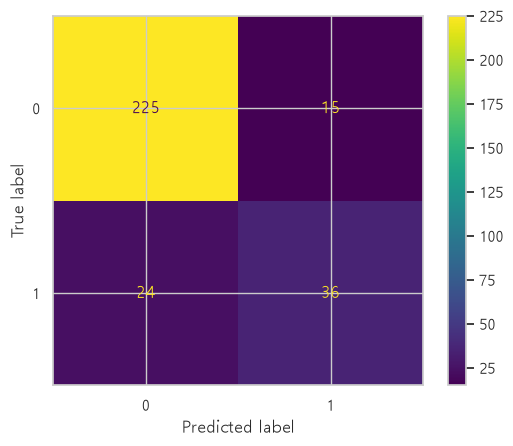

In [170]:
# 코드
from sklearn.metrics import ConfusionMatrixDisplay
# import matplotlib.pyplot as plt
ConfusionMatrixDisplay(cm).plot()
plt.show()

### 예시로 네 칸 채우기
여섯 대를 한 칸씩 분류 → TP=2, FN=1, FP=1, TN=2 — 함수 결과와 일치 확인


In [171]:
# 코드
y_true = [1, 1, 1, 0, 0, 1]
y_hat = [0, 0, 1, 0, 1, 0]
# 직접 분류 : TP=1, FN=3, FP=1 TN=1

print(confusion_matrix(y_true, y_hat))

[[1 1]
 [3 1]]


### 혼동행렬 생성
우리 모델 예측으로 혼동행렬 출력 — 2×2 배열 확인

In [172]:
# 코드
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[225  15]
 [ 24  36]]


### heatmap 시각화
진한 칸이 어디인지 눈으로 확인 — FN 칸이 진하면 놓침 많다는 신호

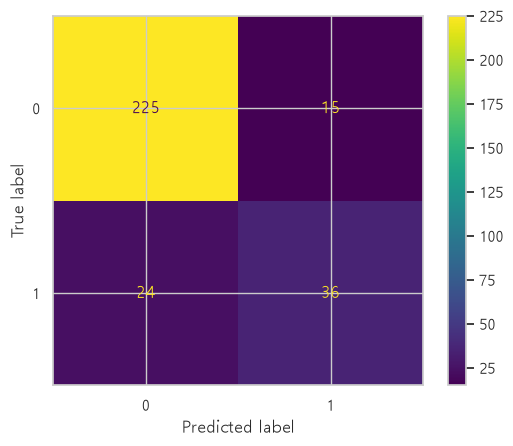

In [173]:
# 코드
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(cm).plot()
plt.show()

### 네 칸 추출
ravel로 네 칸을 각 변수에 담기 — 순서 tn, fp, fn, tp 엄수


In [174]:
# 코드
tn, fp, fn, tp = cm.ravel()
print("TP:", tp, "FP:", fp)
print("FN:", fn, "TN:", tn)

TP: 36 FP: 15
FN: 24 TN: 225


### 설비 대수로 해석 출력
각 칸을 현장 언어 문장으로 — 숫자가 현장의 의미로 바뀌는 순간


In [175]:
# 코드
print(f"잡은 고장 {tp}대, 헛경보 {fp}대")
print(f"놓친 고장 {fn}대, 정상 확인 {tn}대")

잡은 고장 36대, 헛경보 15대
놓친 고장 24대, 정상 확인 225대


# 03 정밀도와 재현율
경보의 신뢰도와 놓치지 않는 능력 — 두 지표의 짝과 트레이드오프


In [176]:
# precision_score() 사용법
from sklearn.metrics import precision_score
p = precision_score(y_test, y_pred)
print("정밀도:", round(p, 4))
# 양성(1) 기준, 분모 0이면 경고 후 0

정밀도: 0.7059


### 네 칸으로 손계산
공식에 네 칸을 직접 대입 — 정밀도 = TP/(TP+FP), 재현율 = TP/(TP+FN)


In [177]:
# 코드
from sklearn.metrics import recall_score
r = recall_score(y_test, y_pred)
print("재현율:", round(r, 4))
# 정답 먼저, 예측 나중 - 순서 동일

재현율: 0.6


### 함수와 대조
손계산과 함수 결과 비교 — 일치하면 공식을 완전히 이해


In [180]:
# 코드
tn, fp, fn, tp = cm.ravel()
print(tn, fp, fn, tp)

precision = tp / (tp + fp)
recall = tp / (tp + fn)
print(precision)
print(recall)

225 15 24 36
0.7058823529411765
0.6


In [182]:
from sklearn.metrics import precision_score, recall_score
print("함수 정밀도:", round(precision_score(y_test, y_pred), 4))
print("함수 재현율:", round(recall_score(y_test, y_pred), 4))

함수 정밀도: 0.7059
함수 재현율: 0.6


### 세 지표 한 화면 출력
정확도·정밀도·재현율을 함께 출력 — 정확도 높은데 재현율 낮은 식의 치우침 확인


In [184]:
# 코드
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("정확도:", round(accuracy_score(y_test, y_pred), 4))
print("정밀도:", round(precision_score(y_test, y_pred), 4))
print("재현율:", round(recall_score(y_test, y_pred), 4))

정확도: 0.87
정밀도: 0.7059
재현율: 0.6
